In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl
import ast


interactions = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/clustered-interactions_pt2/cropped_interactions.csv')





           n_interactions  n_contact  p_contact
condition                                      
G                   353.4      209.2      0.588
S                   332.5      178.9      0.537
n_contact: G vs S  U=71.0  p=0.1209  ns
p_contact: G vs S  U=68.0  p=0.1859  ns


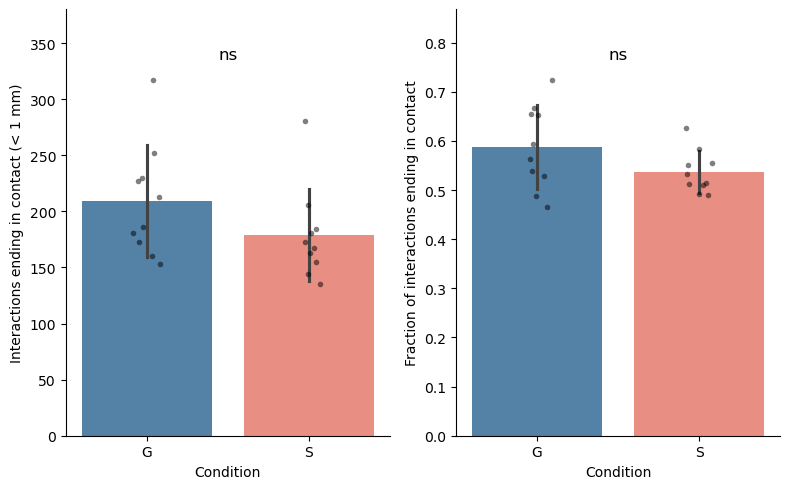

In [2]:
from scipy.stats import mannwhitneyu

## INTERACTIONS THAT END IN CONTACT (< 1 mm), PER FILE

CONTACT_DIST = 1.0          # mm
CONDITIONS = ['G', 'S']     # GS left out
condition_colors = {'G': 'steelblue', 'S': 'salmon'}

d = interactions[interactions['condition'].isin(CONDITIONS)]

# one row per interaction: did it ever get below 1 mm?
per_interaction = (
    d.groupby(['condition', 'file', 'interaction_id'], as_index=False)
     .agg(min_dist=('min_distance', 'min'))
)
per_interaction['contact'] = per_interaction['min_dist'] < CONTACT_DIST

# per file: how many interactions, how many ended in contact
per_file = (
    per_interaction.groupby(['condition', 'file'], as_index=False)
                   .agg(n_interactions=('contact', 'size'), n_contact=('contact', 'sum'))
)
per_file['p_contact'] = per_file['n_contact'] / per_file['n_interactions']

print(per_file.groupby('condition')[['n_interactions', 'n_contact', 'p_contact']].mean().round(3))

fig, axes = plt.subplots(1, 2, figsize=(8, 5))

for ax, measure, label in zip(axes,
                              ['n_contact', 'p_contact'],
                              ['Interactions ending in contact (< 1 mm)', 'Fraction of interactions ending in contact']):

    sns.barplot(data=per_file, x='condition', y=measure, order=CONDITIONS,
                hue='condition', hue_order=CONDITIONS, palette=condition_colors,
                errorbar='sd', legend=False, ax=ax)
    sns.stripplot(data=per_file, x='condition', y=measure, order=CONDITIONS,
                  color='black', size=4, alpha=0.5, ax=ax)

    u, p = mannwhitneyu(per_file.loc[per_file['condition'] == 'G', measure],
                        per_file.loc[per_file['condition'] == 'S', measure])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f'{measure}: G vs S  U={u:.1f}  p={p:.4g}  {sig}')

    ax.text(0.5, per_file[measure].max() * 1.05, sig, ha='center', va='bottom', fontsize=12)
    ax.set_ylim(0, per_file[measure].max() * 1.2)
    ax.set_ylabel(label)
    ax.set_xlabel('Condition')

sns.despine()
plt.tight_layout()
plt.show()
